In [14]:
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import scipy.stats as stats

In [15]:
#open the output file

import os

file_path = '/home/apoorva/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/SHM/SHM_T1.pkl'
with open(file_path, 'rb') as f:
    class RenamingUnpickler(pkl.Unpickler):
        def find_class(self, module, name):
            if module.startswith("numpy._core"):
                module = module.replace("numpy._core", "numpy.core")
            return super().find_class(module, name)

    data_neutral = RenamingUnpickler(f).load()

# file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/2bins/SHM/SHM_T1_newsplines.pkl'
# with open(file_path, 'rb') as f:
#     data_neutral1= pkl.load(f)

# file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/2bins/SHM_T2_newsplines.pkl'
# with open(file_path, 'rb') as f:
#     data_neutral_T2 = pkl.load(f)

# file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/2bins/SHM_FO_newspline2.pkl'
# with open(file_path, 'rb') as f:
#     data_neutral_fo = pkl.load(f)
    
# file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/2bins/SHM_T2MZP_newsplines.pkl'
# with open(file_path, 'rb') as f:
#     data_neutral_T2MZP = pkl.load(f)
    
# file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/TDM_T1_influx.pkl'
# with open(file_path, 'rb') as f:
#     data_neutral_TDI = pkl.load(f)
    
# file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/TDM_T1_division_hill.pkl'
# with open(file_path, 'rb') as f:
#     data_neutral_TDD = pkl.load(f)


In [16]:
posterior = data_neutral.draws_pd()

print(data_neutral.k_hat_pred1.shape)
print(data_neutral. MZ_counts_pred1.shape)
# #save the posterior draws to a csv file
weights = np.array([1, 1, 1, 1])

result = (
    data_neutral.k_hat_pred1
    .reshape(data_neutral.k_hat_pred1.shape[0], 698, 4)
    * weights
).sum(axis=2)

print(result.shape)
print("Arrays are equal (allowing for floating-point precision):", 
      np.allclose(data_neutral.MZ_counts_pred1, result))
# posterior.to_csv('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/SHM_T2_posterior_draws.csv', index=False) 

(5000, 2792)
(5000, 698)
(5000, 698)
Arrays are equal (allowing for floating-point precision): True


In [17]:
# k_hat_pred1: shape = (n_draws, 4 * n_bins)
Mz_counts_pred = data_neutral.k_hat_pred1.reshape(data_neutral.k_hat_pred1.shape[0], -1, 4).sum(axis=2)
print(Mz_counts_pred.shape)

i = 0
MZ_counts_pred_i = data_neutral.k_hat_pred1[:, 4*i:4*i+4].sum(axis=1)

print(np.allclose(data_neutral.MZ_counts_pred1[:, i], MZ_counts_pred_i))

(5000, 698)
True


In [18]:
# open experimental data file 
df = pd.read_csv('/home/apoorva/Desktop/MZB-new-analysis/data/new_data_MZB.csv')
df = df.sort_values(by='Age at S1K')
print(df)


                                    Unnamed: 0  Age at BMT  Age at S1K  \
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
1       20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
2           20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
4             20181207_3wks_SPLEEN_001_048.fcs          74          95   
6             20181213_4wks_SPLEEN_001_024.fcs          74         102   
8        20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002

In [19]:
#Add one column in df_Ki67 and df_Nfd for grouping the data based on age at bmt

df['agebin'] = pd.cut(df['Age at BMT'], bins=[0,70, 140], labels=['<10 weeks', '>10 weeks'])
print(df)

                                    Unnamed: 0  Age at BMT  Age at S1K  \
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
1       20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
2           20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
4             20181207_3wks_SPLEEN_001_048.fcs          74          95   
6             20181213_4wks_SPLEEN_001_024.fcs          74         102   
8        20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002

In [20]:
my_pal = ['#FAA51A','#2e2976']

/tmp/ipykernel_1269229/804140487.py:19: UserWarning: 
The palette list has fewer values (2) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(ax= ax1, data=df, x='Age at S1K', y='total_MZ', hue='Age at BMT', palette= my_pal, s=75, edgecolor='black', legend=False,linewidth=0.5)
/tmp/ipykernel_1269229/804140487.py:96: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_3.set_xlim(0, 800)
/tmp/ipykernel_1269229/804140487.py:115: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_4.set_xlim(0, 800)


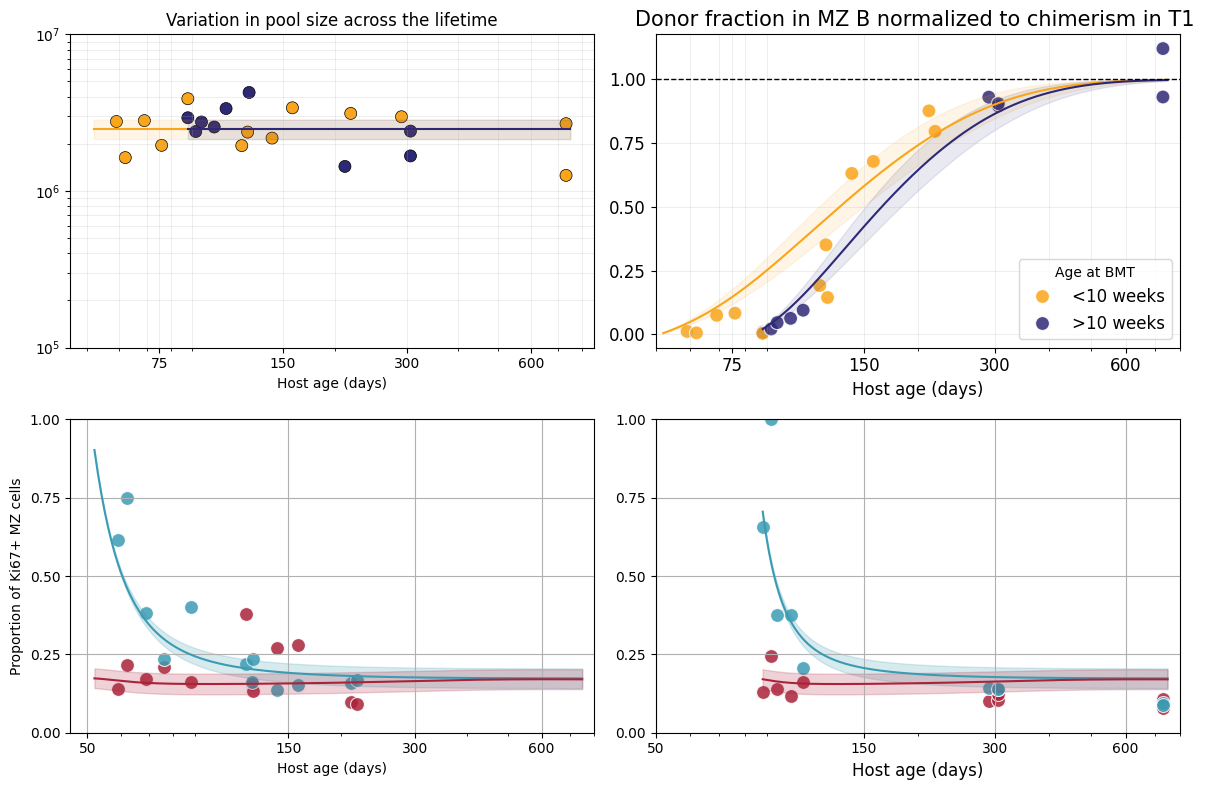

In [21]:
ts1= np.arange(52, 750, 1)
ts2= np.arange(88, 750, 1)
ts3= np.arange(291, 750, 1)

# Plotting
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 6)  # Create a GridSpec with 2 rows and 4 columns

# Create the subplots
ax1 = fig.add_subplot(gs[0, 0:3])  # First row, spanning columns 0 to 1
ax2 = fig.add_subplot(gs[0, 3:6])  # First row, spanning columns 2 to 3
# second row has 3 plots based on the age at BMT
ax_3 = fig.add_subplot(gs[1, 0:3])  # First row, spanning columns 0 to 1
ax_4 = fig.add_subplot(gs[1, 3:6])  # First row, spanning columns 2 to 3


# Plot total MZ cell counts
# sns.scatterplot(ax=ax1, data=df, x='Age at S1K', y='total_MZ', alpha=0.85, hue ='agebin', s=100, legend=False, palette=my_pal)
sns.scatterplot(ax= ax1, data=df, x='Age at S1K', y='total_MZ', hue='Age at BMT', palette= my_pal, s=75, edgecolor='black', legend=False,linewidth=0.5)

ax1.plot(ts1, np.mean(data_neutral.MZ_counts_pred1, axis=0), color = my_pal[0])
ax1.plot(ts2, np.mean(data_neutral.MZ_counts_pred2, axis=0), color = my_pal[1])

ax1.fill_between(ts1, np.quantile(data_neutral.MZ_counts_pred1, 0.025, axis=0), np.quantile(data_neutral.MZ_counts_pred1, 0.975, axis=0), alpha=0.1, color = my_pal[0])
ax1.fill_between(ts2, np.quantile(data_neutral.MZ_counts_pred2, 0.025, axis=0), np.quantile(data_neutral.MZ_counts_pred2, 0.975, axis=0), alpha=0.1, color = my_pal[1])           

ax1.set_ylim(1e5, 1e7)
ax1.set_yscale('log')  # sets the y-axis to a logarithmic scale
# ax1.set_xlim(0, 800)
ax1.set_xscale('log')
ax1.set_xticks([75, 150, 300, 600])
ax1.set_xticklabels([75, 150, 300, 600])
ax1.set_ylabel('')
ax1.tick_params(axis='both')
ax1.set_xlabel('Host age (days)')
ax1.set_title('Variation in pool size across the lifetime')
ax1.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
yticks = np.concatenate([np.arange(1, 10, 1)*1e5, np.arange(1, 11, 1)*1e6])
plt.yticks(yticks)
#plt.grid(True, axis="y", ls="-")
plt.tight_layout()
# no legend for points
plt.legend([],[], frameon=False)
# save the figure
# #  plot legend as colorbar
# norm = plt.Normalize(df['Age at BMT'].min()/7, df['Age at BMT'].max()/7)
# sm = plt.cm.ScalarMappable(cmap=my_cmap, norm=norm)
# sm.set_array([])
# ax1 = plt.gca()
# cbar = plt.colorbar(sm, ax=ax1)
# cbar.set_label('Age at BMT (weeks)')
# plt.grid(True, axis="x", ls="-.")

# Plot normalized donor fraction
sns.scatterplot(ax=ax2, data=df, x='Age at S1K', y='Nfd_MZ', hue='agebin', alpha=0.85, s=100, legend= True, palette=my_pal)
ax2.plot(ts1, np.mean(data_neutral.Nfd_pred1, axis=0), color=my_pal[0])
ax2.plot(ts2, np.mean(data_neutral.Nfd_pred2, axis=0), color=my_pal[1])
# ax2.plot(ts3, np.mean(data_neutral.Nfd_pred3, axis=0), color=my_pal[2])
# ax2.plot(ts1, np.mean(data_neutral_T2.Nfd_pred1, axis=0), color=my_pal[0])
# ax2.plot(ts2, np.mean(data_neutral_T2.Nfd_pred2, axis=0), color=my_pal[1])
# ax2.plot(ts3, np.mean(data_neutral_T2.Nfd_pred3, axis=0), color=my_pal[2])
ax2.fill_between(ts1, np.quantile(data_neutral.Nfd_pred1, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred1, 0.975, axis=0), alpha=0.1, color= my_pal[0])
ax2.fill_between(ts2, np.quantile(data_neutral.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred2, 0.975, axis=0), alpha=0.1, color = my_pal[1])
# ax2.fill_between(ts3, np.quantile(data_neutral.Nfd_pred3, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred3, 0.975, axis=0), alpha=0.1, color = my_pal[2])
# ax2.fill_between(ts1, np.quantile(data_neutral_T2.Nfd_pred1, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred1, 0.975, axis=0), alpha=0.1, color= my_pal[0])
# ax2.fill_between(ts2, np.quantile(data_neutral_T2.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred2, 0.975, axis=0), alpha=0.1, color = my_pal[1])
# ax2.fill_between(ts3, np.quantile(data_neutral_T2.Nfd_pred3, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred3, 0.975, axis=0), alpha=0.1, color = my_pal[2])
ax2.set_xlim(50, 800)
ax2.set_xscale('log')
ax2.set_xticks([75, 150,  300,  600])
ax2.set_xticklabels([75, 150,  300,  600])
ax2.set_ylabel('')
ax2.set_yticks(np.arange(0, 1.25, 0.25))
ax2.set_xlabel('Host age (days)', fontsize=12)
ax2.set_title('Donor fraction in MZ B normalized to chimerism in T1 ', fontsize=15)
ax2.axhline(y=1, color='black', linestyle='dashed', linewidth=1)
ax2.tick_params(axis='both', labelsize=12)
ax2.legend(title='Age at BMT', fontsize=12)
ax2.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)      

#Construct a new dataframe for agebin1, agebin2 and agebin3
df_Ki67_bin1 = df[df['agebin'] == '<10 weeks']
df_Ki67_bin2 = df[df['agebin'] == '>10 weeks']


# Plot Proportion of Ki67+ MZ cells for age bin1
sns.scatterplot(ax=ax_3, data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_host', alpha=0.85, s=100, color='#ab2239')
sns.scatterplot(ax=ax_3, data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_donor', alpha=0.85, s=100, color='#3b9bb3')
ax_3.plot(ts1, np.mean(data_neutral.donor_ki_pred1, axis=0), color= '#3b9bb3')
ax_3.fill_between(ts1, np.quantile(data_neutral.donor_ki_pred1, 0.025, axis=0), np.quantile(data_neutral.donor_ki_pred1, 0.975, axis=0), color= '#3b9bb3', alpha=0.2)
ax_3.plot(ts1, np.mean(data_neutral.host_ki_pred1, axis=0), color = '#ab2239')
ax_3.fill_between(ts1, np.quantile(data_neutral.host_ki_pred1, 0.025, axis=0), np.quantile(data_neutral.host_ki_pred1, 0.975, axis=0), color= '#ab2239', alpha=0.2)
ax_3.set_ylim(0, 1)
ax_3.set_yticks(np.arange(0, 1.25, 0.25))
ax_3.set_xscale('log')
ax_3.set_xlim(0, 800)
ax_3.set_xticks([50, 150, 300, 600])
ax_3.set_xticklabels([50, 150, 300, 600])
ax_3.set_ylabel('Proportion of Ki67+ MZ cells')
ax_3.set_xlabel('Host age (days)')
# ax_3.set_title('Extent of cell division', fontsize=14, fontweight='bold')
ax_3.grid(True, ls="solid")


# Plot Proportion of Ki67+ MZ cells for age bin2
sns.scatterplot(ax=ax_4, data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_host', alpha=0.85, s=100, color='#ab2239')
sns.scatterplot(ax=ax_4, data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_donor', alpha=0.85, s=100, color='#3b9bb3')
ax_4.plot(ts2, np.mean(data_neutral.donor_ki_pred2, axis=0), color= '#3b9bb3')
ax_4.fill_between(ts2, np.quantile(data_neutral.donor_ki_pred2, 0.025, axis=0), np.quantile(data_neutral.donor_ki_pred2, 0.975, axis=0), color= '#3b9bb3', alpha=0.2)
ax_4.plot(ts2, np.mean(data_neutral.host_ki_pred2, axis=0), color = '#ab2239')
ax_4.fill_between(ts2, np.quantile(data_neutral.host_ki_pred2, 0.025, axis=0), np.quantile(data_neutral.host_ki_pred2, 0.975, axis=0), color= '#ab2239', alpha=0.2)
ax_4.set_ylim(0, 1)
ax_4.set_yticks(np.arange(0, 1.25, 0.25))
ax_4.set_xscale('log')
ax_4.set_xlim(0, 800)
ax_4.set_xticks([50, 150, 300, 600])
ax_4.set_xticklabels([50, 150, 300, 600])
ax_4.set_ylabel('')
ax_4.set_xlabel('Host age (days)', fontsize=12)
# ax_4.set_title('Extent of cell division', fontsize=15, fontweight='bold')
ax_4.grid(True, ls="solid")


plt.tight_layout()


/tmp/ipykernel_1269229/798626950.py:34: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(0, 800)
/tmp/ipykernel_1269229/798626950.py:52: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(0, 800)
/tmp/ipykernel_1269229/798626950.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax3.set_xlim(0, 800)


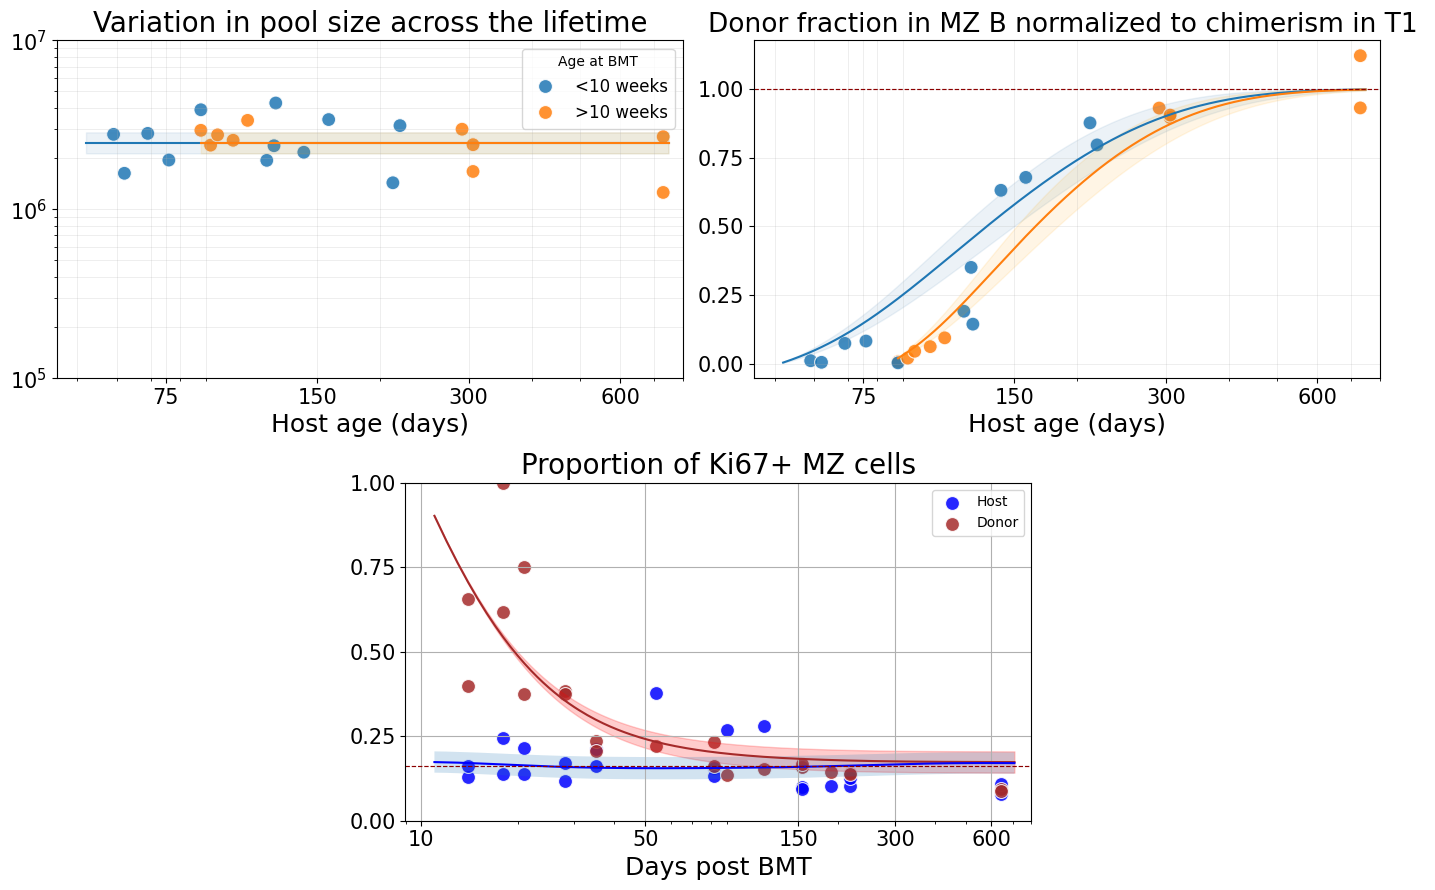

In [22]:

from matplotlib import gridspec

tb1 = np.arange(52, 750,1) - 41
tb2 = np.arange(88, 750,1) - 74

# tb1 = np.arange(55, 750,1) - 41  #(41 is the minimum age at BMT)
# tb1 = np.arange(88, 750,1) - 74
# tb3 = np.arange(291, 750,1) - 89

#plot 4*4 grid 

# Create a figure with a custom grid layout
fig = plt.figure(figsize=(14, 9))
gs = gridspec.GridSpec(2, 4)  # Define a 2x4 grid

# Top row: Two plots
ax1 = fig.add_subplot(gs[0, 0:2])  # First plot spans columns 0 and 1
ax2 = fig.add_subplot(gs[0, 2:4])  # Second plot spans columns 2 and 3

# Bottom row: One centered plot
ax3 = fig.add_subplot(gs[1, 1:3])  # Centered plot spans columns 1 and 2

# Plot total MZ cell counts
sns.scatterplot(ax=ax1, data=df, x='Age at S1K', y='total_MZ', alpha=0.85, hue ='agebin', s=100)
ax1.plot(ts1, np.mean(data_neutral.MZ_counts_pred1, axis=0))
ax1.plot(ts2, np.mean(data_neutral.MZ_counts_pred2, axis=0))
# ax1.plot(tb3, np.mean(data_neutral.MZ_counts_pred3, axis=0), color='Green')
ax1.fill_between(ts1, np.quantile(data_neutral.MZ_counts_pred1, 0.025, axis=0), np.quantile(data_neutral.MZ_counts_pred1, 0.975, axis=0), alpha=0.1, color = 'steelblue')
ax1.fill_between(ts2, np.quantile(data_neutral.MZ_counts_pred2, 0.025, axis=0), np.quantile(data_neutral.MZ_counts_pred2, 0.975, axis=0), alpha=0.1, color= 'orange')           
# ax1.fill_between(tb3, np.quantile(data_neutral.MZ_counts_pred3, 0.025, axis=0), np.quantile(data_neutral.MZ_counts_pred3, 0.975, axis=0), alpha=0.1, color = 'green')
ax1.set_yscale('log')  # sets the y-axis to a logarithmic scale
ax1.set_ylim(1e5, 1e7)
ax1.set_xscale('log')
ax1.set_xlim(0, 800)
ax1.set_xticks([75, 150, 300, 600])
ax1.set_xticklabels([75, 150, 300, 600])
ax1.set_ylabel('')
ax1.tick_params(axis='both', labelsize=15)
ax1.legend(title='Age at BMT', fontsize=12)
ax1.set_xlabel('Host age (days)', fontsize=18)
ax1.set_title('Variation in pool size across the lifetime', fontsize=20)
ax1.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# Plot normalized donor fraction
sns.scatterplot(ax=ax2, data=df, x='Age at S1K', y='Nfd_MZ', hue='agebin', alpha=0.85, s=100, legend=False)
ax2.plot(ts1, np.mean(data_neutral.Nfd_pred1, axis=0))
ax2.plot(ts2, np.mean(data_neutral.Nfd_pred2, axis=0))
# ax2.plot(tb3, np.mean(data_neutral.Nfd_pred3, axis=0))
ax2.fill_between(ts1, np.quantile(data_neutral.Nfd_pred1, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred1, 0.975, axis=0), alpha=0.1, color= 'steelblue')
ax2.fill_between(ts2, np.quantile(data_neutral.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred2, 0.975, axis=0), alpha=0.1, color = 'orange')
# ax2.fill_between(tb3, np.quantile(data_neutral.Nfd_pred3, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred3, 0.975, axis=0), alpha=0.1, color = 'green')
ax2.set_xscale('log')
ax2.set_xlim(0, 800)
ax2.set_xticks([75, 150,  300,  600])
ax2.set_xticklabels([75, 150,  300,  600])
ax2.set_ylabel('')
ax2.set_yticks(np.arange(0, 1.25, 0.25))
ax2.set_xlabel('Host age (days)', fontsize=18)
ax2.set_title('Donor fraction in MZ B normalized to chimerism in T1 ', fontsize=19)
ax2.axhline(y=1, color='darkred', linestyle='dashed', linewidth=0.85)
ax2.tick_params(axis='both', labelsize=15)
ax2.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)      
# ax2.legend(title='Age at BMT', fontsize=12)
#Construct a new dataframe for agebin1, agebin2 and agebin3
# df_Ki67_bin1 = df[df['agebin'] == 'agebin1 = [41,61]']
# df_Ki67_bin2 = df[df['agebin'] == 'agebin2 = [62,81]']    
# df_Ki67_bin3 = df[df['agebin'] == 'agebin3 = [82,101]']
# Plot Proportion of Ki67+ MZ cells
sns.scatterplot(ax=ax3, data=df, x='Days postBMT', y='frac_Ki67+_MZ_host', alpha=0.85, s=100, color='blue')
sns.scatterplot(ax=ax3, data=df, x='Days postBMT', y='frac_Ki67+_MZ_donor', alpha=0.85, s=100, color='brown')
ax3.plot(tb1, np.mean(data_neutral.donor_ki_pred1, axis=0), color= 'brown')
ax3.fill_between(tb1, np.quantile(data_neutral.donor_ki_pred1, 0.025, axis=0), np.quantile(data_neutral.donor_ki_pred1, 0.975, axis=0), color= 'red', alpha=0.2)
ax3.plot(tb1, np.mean(data_neutral.host_ki_pred1, axis=0), color = 'blue')
ax3.fill_between(tb1, np.quantile(data_neutral.host_ki_pred1, 0.025, axis=0), np.quantile(data_neutral.host_ki_pred1, 0.975, axis=0), alpha=0.2)
ax3.axhline(y=np.mean(data_neutral.kappa_0), color='darkred', linestyle='dashed', linewidth=0.85)
ax3.set_ylim(0, 1)
ax3.set_yticks(np.arange(0, 1.25, 0.25))
ax3.set_xscale('log')
ax3.set_xlim(0, 800)
ax3.set_xticks([10, 50, 150, 300, 600])
ax3.set_xticklabels([10, 50, 150, 300, 600])
ax3.tick_params(axis='both', labelsize=15)  # Set font size for both x and y-axis tick labels
ax3.set_ylabel('')
ax3.set_xlabel('Days post BMT', fontsize=18)
ax3.set_title('Proportion of Ki67+ MZ cells', fontsize=20)
ax3.grid(True, ls="solid")
ax3.legend(labels=['Host', 'Donor'])

plt.tight_layout()


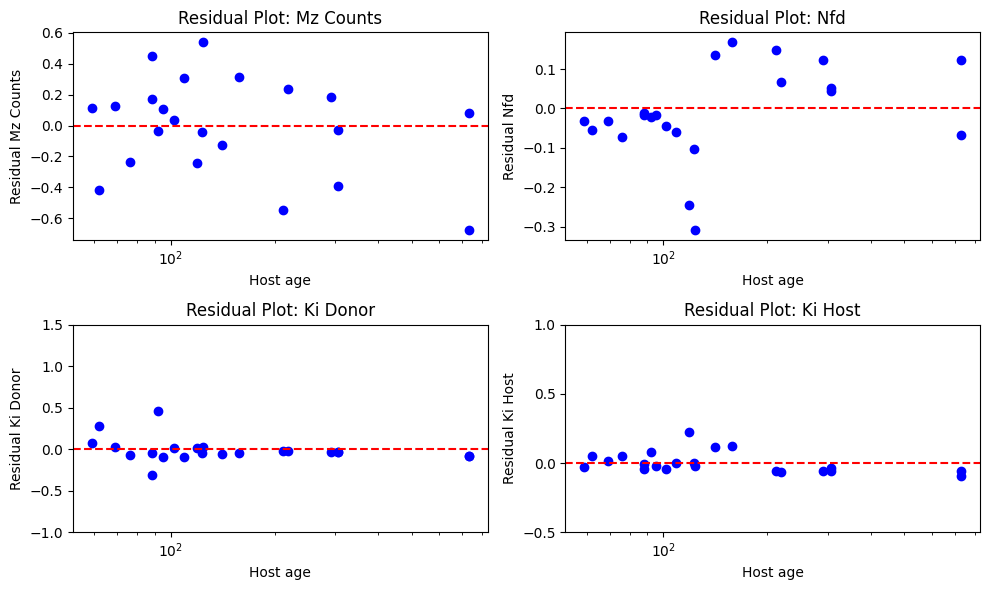

In [23]:


fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Plot Residual Ki Donor
axes[1, 0].scatter(x=df['Age at S1K'], y=np.mean(data_neutral.residuals_Kid, axis=0), marker='o', color='b')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Host age')
axes[1, 0].set_xscale('log')
axes[1, 0].set_yticks([-1, -0.5, 0, 0.5, 1.0, 1.5])
axes[1, 0].set_ylabel('Residual Ki Donor')
axes[1, 0].set_title('Residual Plot: Ki Donor')

# Plot Residual Ki Host
axes[1, 1].scatter(x=df['Age at S1K'], y=np.mean(data_neutral.residuals_Kih, axis=0), marker='o', color='b')
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Host age')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yticks([-0.5, 0, 0.5, 1.0])
axes[1, 1].set_ylabel('Residual Ki Host')
axes[1, 1].set_title('Residual Plot: Ki Host')

# Plot Residual Nfd
axes[0, 1].scatter(x=df['Age at S1K'], y=np.mean(data_neutral.residuals_Nfd, axis=0), marker='o', color='b')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Host age')
axes[0,1].set_xscale('log')
axes[0, 1].set_ylabel('Residual Nfd')
axes[0, 1].set_title('Residual Plot: Nfd')

# Plot Residual Mz Counts
axes[0, 0].scatter(x=df['Age at S1K'], y=np.mean(data_neutral.residuals_Mz, axis=0), marker='o', color='b')
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Host age')
axes[0,0].set_xscale('log')
axes[0, 0].set_ylabel('Residual Mz Counts')
axes[0, 0].set_title('Residual Plot: Mz Counts')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# Load the observed data into an xarray structure if not already in data_dict
observed_data = {"MZcounts": np.log(df["total_MZ"])}

# Create the InferenceData object, mapping 'y' to observed_data and 'y_predict' to posterior_predictive
idata = az.from_cmdstanpy(
    posterior=posterior,
    posterior_predictive=["y1_rep"],
    observed_data=observed_data
)

# Plot the posterior predictive check
az.plot_ppc(idata, data_pairs={"MZcounts": "y1_rep"}, figsize=(10, 6))
plt.show()

AttributeError: 'InferenceMetadata' object has no attribute 'stan_vars_cols'

In [ ]:
# Define logit function
def logit_boundary(x, b=1.5):
    return np.log(x / (b - x))

def arcsinsqrt_boundary(x):
    return np.arcsin(np.sqrt(x))
# Load the observed data into an xarray structure if not already in data_dict
observed_data = {"Nfd": df["Nfd_MZ"]}

# Create the InferenceData object, mapping 'y' to observed_data and 'y_predict' to posterior_predictive
idata = az.from_cmdstanpy(
    posterior=data_neutral,
    posterior_predictive=["y2_rep"],
    observed_data=observed_data
)

# Plot the posterior predictive check
az.plot_ppc(idata, data_pairs={"Nfd": "y2_rep"}, figsize=(10, 6))
plt.show()

In [ ]:


# Load the observed data into an xarray structure if not already in data_dict
observed_data = {"Ki67_donor": arcsinsqrt_boundary(df["frac_Ki67+_MZ_donor"])}

# Create the InferenceData object, mapping 'y' to observed_data and 'y_predict' to posterior_predictive
idata = az.from_cmdstanpy(
    posterior=data_neutral,
    posterior_predictive=["y3_rep"],
    observed_data=observed_data
)

# Plot the posterior predictive check
az.plot_ppc(idata, data_pairs={"Ki67_donor": "y3_rep"}, figsize=(10, 6))
plt.show()



In [ ]:
# observed_data = {"Ki67_host": logit_boundary(df["frac_Ki67+_MZ_host"])}
observed_data = {"Ki67_host": arcsinsqrt_boundary(df["frac_Ki67+_MZ_host"])}


# Create the InferenceData object, mapping 'y' to observed_data and 'y_predict' to posterior_predictive
idata = az.from_cmdstanpy(
    posterior=data_neutral,
    posterior_predictive=["y4_rep"],
    observed_data=observed_data
)

# Plot the posterior predictive check
az.plot_ppc(idata, data_pairs={"Ki67_host": "y4_rep"}, figsize=(10, 6))
plt.show()

In [ ]:
# Calculate elpdf for the model

idata = az.from_cmdstanpy(data_neutral, log_likelihood={"log_lik_Mz": "log_lik_Mz", "log_lik_Nfd": "log_lik_Nfd", "log_lik_Kid": "log_lik_Kid", "log_lik_Kih": "log_lik_Kih"})

# Compute Loo CV for models with several Likelihoods 
import xarray as xr

# Concatenate the log_likelihood arrays

a1 = np.array(idata.log_likelihood["log_lik_Mz"])
a2 = np.array(idata.log_likelihood["log_lik_Nfd"])
a3 = np.array(idata.log_likelihood["log_lik_Kid"])
a4 = np.array(idata.log_likelihood["log_lik_Kih"])

# log_lik = np.concatenate((a1, a2, a3, a4), axis=2)
log_lik = a1 + a2 + a3 + a4  # Sum the log-likelihoods across the different likelihoods


# Convert the concatenated array to an xarray DataArray
idata.log_likelihood["combined_log_lik"] = xr.DataArray(log_lik, dims=["chain", "draw", "log_likelihood_dim"], coords={"chain": np.arange(log_lik.shape[0]), "draw": np.arange(log_lik.shape[1]), "log_likelihood_dim": np.arange(log_lik.shape[2])})

# Compute loo_cv
loo = loo_result1_combined = az.loo(idata, var_name="combined_log_lik")
print(loo)

In [ ]:
# Calculate elpdf for the model
idata = az.from_cmdstanpy(data_neutral, log_likelihood={"log_lik_total": "log_lik_total"})

# Compute LOO
loo = az.loo(idata, var_name="log_lik_total", pointwise=True)
print(loo)

In [ ]:
#Plot the posterior distribution of the parameters

# az.plot_posterior(data_neutral, var_names=['rho', 'phi','delta','kappa_0', 'y0', 'K'], kind='kde')

az.plot_posterior(data_neutral, var_names=['rho','phi', 'kappa_0', 'y0'], kind='kde')


# az.plot_posterior(data_neutral, var_names=['rho_fast', 'phi', 'y0', 'rho_slow'], kind='kde')
# az.plot_posterior(data_neutral, var_names=['rho', 'phi', 'r_d', 'kappa_0', 'y0'], kind='kde')



# Print mean and standard deviation of the parameters
# print("Mean and standard deviation of the parameters:")
print("rho:", np.mean(data_neutral.rho), np.std(data_neutral.rho))
print("phi:", np.mean(data_neutral.phi), np.std(data_neutral.phi))
# # print("delta:", np.mean(data_neutral.delta), np.std(data_neutral.delta))
# # print("lamda:", np.mean(data_neutral.lamda), np.std(data_neutral.lamda))
# print("kappa_0:", np.mean(data_neutral.kappa_0), np.std(data_neutral.kappa_0))
# print("y0:", np.mean(data_neutral.y0), np.std(data_neutral.y0))
# print('MZ_COUNT', np.mean(data_neutral.MZ_counts_mean), np.std(data_neutral.MZ_counts_mean))


AttributeError: 'InferenceMetadata' object has no attribute 'stan_vars_cols'

In [ ]:
ts = np.arange(40, 731, 0.01)
# def rho_func(t, rho, r_d):
#     return rho * np.exp(-r_d * (t-40)) # Adjusted to start decay after t=40
def influx_func(t, phi, r_d):
    return phi * np.exp(-r_d * (t - 40)) # Adjusted to start decay after t=40

# posterior
influx_posterior = np.zeros((len(ts), len(data_neutral.phi)))
for i in range(len(ts)):
    influx_posterior[i, :] = influx_func(ts[i], data_neutral.phi, data_neutral.r_d)
# Remove the incorrect broadcasting line

# Plot posterior
plt.figure(figsize=(8, 6))
plt.plot(ts, np.mean(influx_posterior, axis=1), label='Posterior', color='steelblue')
plt.fill_between(ts, np.quantile(influx_posterior, 0.025, axis=1), np.quantile(influx_posterior, 0.975, axis=1), alpha=0.3, color='steelblue', label='95% Credible Interval')
plt.xlabel('Host age (days)')
# plt.ylabel('Density')
# plt.xscale('log')
plt.title('Decay in influx rate over time')
# plt.xticks([10, 50, 150, 300, 600], [10, 50, 150, 300, 600])
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.show()

In [ ]:
ts = np.arange(40, 731, 0.01)
# def rho_func(t, rho, r_d):
#     return rho * np.exp(-r_d * (t-40)) # Adjusted to start decay after t=40
def rho_func(t, rho, r_d):
    return rho / (1 + ((t-40)/r_d)) # Adjusted to start decay after t=40

# posterior
rho_posterior = np.zeros((len(ts), len(data_neutral.rho)))
for i in range(len(ts)):
    rho_posterior[i, :] = rho_func(ts[i], data_neutral.rho, data_neutral.r_d)
# Remove the incorrect broadcasting line

# Plot posterior
plt.figure(figsize=(8, 6))
plt.plot(ts, np.mean(rho_posterior, axis=1), label='Posterior', color='steelblue')
plt.fill_between(ts, np.quantile(rho_posterior, 0.025, axis=1), np.quantile(rho_posterior, 0.975, axis=1), alpha=0.3, color='steelblue', label='95% Credible Interval')
plt.xlabel('Host age (days)')
# plt.ylabel('Density')
# plt.xscale('log')
plt.title('Decay in division rate (rho) over time')
# plt.xticks([10, 50, 150, 300, 600], [10, 50, 150, 300, 600])
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.show()

In [ ]:
# Plot posterior
plt.figure(figsize=(8, 6))
plt.plot(ts1, np.mean(data_neutral.rho_rate, axis=1), label='Posterior', color='steelblue')
plt.fill_between(ts1, np.quantile(data_neutral.rho_rate, 0.025, axis=1), np.quantile(data_neutral.rho_rate, 0.975, axis=1), alpha=0.3, color='steelblue', label='95% Credible Interval')
plt.xlabel('Host age (days)')
# plt.ylabel('Density')
plt.title('Decay in division rate (rho) over time')
plt.xticks([10, 50, 150, 300, 600], [10, 50, 150, 300, 600])
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.show()

In [ ]:
phi_samples = data_neutral.stan_variable('phi')
rho_samples = data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')
K_samples = data_neutral.stan_variable('K')

b = rho_samples * (1 - M_stable_samples[:,5] / K_samples)

az.plot_posterior(b, kind='kde')
print("Death:", np.mean(b), np.std(b))


# # Plot the posterior distribution for alpha
# az.plot_posterior(phi, kind='kde')

# # Remove X from the plot

plt.ylabel('Density')
plt.title('b(M)')
plt.show()

In [ ]:
#Plot error bars for daily influx across all models 
phi_samples = data_neutral.stan_variable('phi')
rho_samples = data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')

phi_samples_T2 = data_neutral_T2.stan_variable('phi')
rho_samples_T2 = data_neutral_T2.stan_variable('rho')
M_stable_samples_T2 = data_neutral_T2.stan_variable('MZ_counts_pred1')

phi_samples_FO = data_neutral_FO.stan_variable('phi')
rho_samples_FO = data_neutral_FO.stan_variable('rho')
M_stable_samples_FO = data_neutral_FO.stan_variable('MZ_counts_pred1')

phi_samples_T2MZP = data_neutral_T2MZP.stan_variable('phi')
rho_samples_T2MZP = data_neutral_T2MZP.stan_variable('rho')
M_stable_samples_T2MZP = data_neutral_T2MZP.stan_variable('MZ_counts_pred1')

ts= np.arange(59, 731, 1)

def theta_spline(time):
  theta_est = 17
  nu = 0.00045
  t0 = 40  # t0 is the minimum mouse age
  theta_s = np.exp(theta_est) * np.exp(nu * (time - t0))
  return theta_s

delta_T1 = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
delta_T2 = ((phi_samples_T2 * 1308516) / M_stable_samples_T2[:,0] ) + rho_samples_T2
delta_FO = ((phi_samples_FO * np.mean(theta_spline(ts))) / M_stable_samples_FO[:,0] ) + rho_samples_FO
delta_T2MZP = ((phi_samples_T2MZP * 1788129) / M_stable_samples_T2MZP[:,0] ) + rho_samples_T2MZP


P_T1= phi_samples * 1298783
P_T2 = phi_samples_T2 * 1308516
P_FO = phi_samples_FO * np.mean(theta_spline(ts))
P_T2MZP = phi_samples_T2MZP * 1788129


# # Interdivision time
interdivision_time_T1 = 1 / rho_samples
interdivision_time_T2 = 1 / rho_samples_T2
interdivision_time_FO = 1 / rho_samples_FO
interdivision_time_T2MZP = 1 / rho_samples_T2MZP

# Residence time
residence_time_T1 = 1 / delta_T1
residence_time_T2 = 1 / delta_T2
residence_time_FO = 1 / delta_FO
residence_time_T2MZP = 1 / delta_T2MZP

#Plot P_T2 posterior 
plt.figure(figsize=(8, 6))

# sns.kdeplot(P_T2, label='T2', fill=True, color='orange', alpha=0.5)

az.plot_posterior(P_T2, kind='kde')
print("Daily Influx:", np.mean(P_T2), np.std(P_T2))
# plt.axvline(np.mean(P_T2), color='orange', linestyle='dashed', linewidth=1)

plt.xlabel('Daily influx (cells/day)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Posterior distribution of Daily influx (cells/day)', fontsize=16)
plt.legend()
plt.grid()

In [ ]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(4, 6))

# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange', 'red', 'green']
models = [P_T1, P_T2, P_T2MZP, P_FO]
labels = ['T1', 'T2', 'T2MZP', 'FO']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)

ax.set_ylabel('Cells/day', fontsize=15)
ax.set_xlabel('Model', fontsize=15)
ax.set_title('Daily Influx Comparison Across Models', fontsize=16)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

plt.tight_layout()
plt.show()

In [ ]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(4, 6))

# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange', 'red', 'green']
models = [interdivision_time_T1, interdivision_time_T2, interdivision_time_T2MZP, interdivision_time_FO]
labels = ['T1', 'T2', 'T2MZP', 'FO']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)

ax.set_ylabel('Days', fontsize=15)
ax.set_xlabel('Model', fontsize=15)
ax.set_title('Interdivision time', fontsize=16)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

plt.tight_layout()
plt.show()

In [ ]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(4, 6))

# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange', 'red', 'green']
models = [residence_time_T1, residence_time_T2, residence_time_T2MZP, residence_time_FO]
labels = ['T1', 'T2', 'T2MZP', 'FO']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)

ax.set_ylabel('Days', fontsize=15)
ax.set_xlabel('Model', fontsize=15)
ax.set_title('Residence time', fontsize=16)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate clonal half-life for ontogeny predictions
from numpy import real

phi_samples = data_neutral.stan_variable('phi')
rho_samples = data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')
 
ts= np.arange(59, 731, 1)

def theta_spline(time):
  theta_est = 17
  nu = 0.00045
  t0 = 40  # t0 is the minimum mouse age
  theta_s = np.exp(theta_est) * np.exp(nu * (time - t0))
  return theta_s

# delta = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
# delta = ((phi_samples * 1308516) / M_stable_samples[:,0] ) + rho_samples
delta = ((phi_samples * np.mean(theta_spline(ts))) / M_stable_samples[:,0] ) + rho_samples


# P = phi_samples * 1298783
# P = phi_samples * 1308516
P = phi_samples * np.mean(theta_spline(ts))

print(np.mean(theta_spline
              (ts)))
# Interdivision time
interdivision_time = 1 / rho_samples

# Residence time
residence_time = 1 / delta

# Plot error plot for interdivision, clonal half-life , residence time

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=8, markersize=6, elinewidth=2.5)
    # ax.set_xlabel('Index', fontsize=12)
    # ax.set_ylabel(label, fontsize=12)


# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(8, 6))

# Plot rho_inv
plot_with_error_bars(interdivision_time, 'rho_inv', 'steelblue', axes[1])


# Plot lamda_inv
# plot_with_error_bars(data_neutral.lamda_inv, 'lamda_inv', 'steelblue', axes[0])
plot_with_error_bars(P, 'Daily Influx', 'steelblue', axes[0])
axes[0].set_ylabel('Cells/day', fontsize=15)
# axes[0].set_ylim(10000, 35000)
# axes[0].set_yticks([12000,  18000, 24000, 30000])
# axes[0].set_yticks([12000,  18000, 24000])
axes[0].set_yticklabels([12000,  18000, 24000, 30000], fontsize=15)
# axes[0].set_yticklabels([12000,  18000, 24000], fontsize=15)

axes[0].set_xticklabels([])
axes[0].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)


# axes[0].set_xlabel('Index', fontsize=8)
# axes[0].legend(['Chimera', 'Young+Chimera'], fontsize=6)
axes[1].set_title('Interdivision time', fontsize=20)
axes[1].set_ylabel('Days', fontsize=15)
axes[1].set_ylim(0, 100)
axes[1].set_yticks([0, 30, 50, 70, 90])
axes[1].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[1].set_xticklabels([])
axes[1].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
axes[0].set_title('Daily influx', fontsize=20)
axes[2].set_title('Residence time', fontsize=20)
axes[2].set_ylim(0, 100)
axes[2].set_yticks([0, 30, 50, 70, 90])
axes[2].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[2].set_xticklabels([])
axes[2].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

# Plot delta_inv
plot_with_error_bars(residence_time, 'delta_inv', 'steelblue', axes[2])

# Adjust layout
plt.tight_layout()
plt.show()

#save the figure
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/ontogeny_clonalhalf_life.png', dpi=350, bbox_inches='tight')

In [ ]:
# Error plot for phi, division, delta between SHM, TDI, TDD

phi_shm = data_neutral.stan_variable('phi')
rho_shm = data_neutral.stan_variable('rho')
M_stable_shm = data_neutral.stan_variable('MZ_counts_pred1')

phi_tdi = data_neutral_TDI.stan_variable('phi')
rho_tdi = data_neutral_TDI.stan_variable('rho')
r_d_tdi = data_neutral_TDI.stan_variable('r_d')
M_stable_tdi = data_neutral_TDI.stan_variable('MZ_counts_pred1')

phi_tdd = data_neutral_TDD.stan_variable('phi')
rho_tdd = data_neutral_TDD.stan_variable('rho')
r_d_tdd = data_neutral_TDD.stan_variable('r_d')
M_stable_tdd = data_neutral_TDD.stan_variable('MZ_counts_pred1')

ts= np.arange(40, 731, 1)
def phi_func(t, phi, r_d):
    return  phi * np.exp(-r_d * (t - 40)) # Adjusted to start decay after t=40

# Calculate phi function values at t=40, 365, 731 for TDI
time_points = [40, 365, 731]
phi_values_tdi = []
for t in time_points:
    phi_t = phi_func(t, phi_tdi, r_d_tdi)
    phi_values_tdi.append(phi_t)
phi_values_tdi = np.array(phi_values_tdi).T  # Shape: (n_samples, 3)


# Plot error plot for interdivision, clonal half-life , residence time

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=8, markersize=6, elinewidth=2.5)
    # ax.set_xlabel('Index', fontsize=12)
    # ax.set_ylabel(label, fontsize=12)

def plot_with_error_bars_timepoints(data, labels, colors, ax):
    for i, (label, color) in enumerate(zip(labels, colors)):
        mean_data = np.mean(data[:, i])
        lower_ci = np.quantile(data[:, i], 0.025)
        upper_ci = np.quantile(data[:, i], 0.975)
        
        ax.errorbar(i, mean_data, yerr=[[mean_data - lower_ci], [upper_ci - mean_data]], 
                    fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                    label=f'{label} days')

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(8, 6))


plot_with_error_bars(phi_shm, 'SHM', 'steelblue', axes[0])
# plot_with_error_bars(phi_tdi, 'TDI', 'orange', axes[1])
plot_with_error_bars_timepoints(phi_values_tdi, 
                     ['40', '365', '731'], 
                     ['red', 'orange', 'green'], 
                     axes[1])

# ax.set_ylabel('φ(t) - Influx Rate', fontsize=15)
plot_with_error_bars(phi_tdd, 'TDD', 'grey', axes[2])

# Plot lamda_inv
# plot_with_error_bars(data_neutral.lamda_inv, 'lamda_inv', 'steelblue', axes[0])
plot_with_error_bars(phi_shm, 'SHM', 'steelblue', axes[0])
axes[0].set_ylabel('Influx Rate', fontsize=15)
axes[0].set_ylim(0, 0.035)
# axes[0].set_yticks([12000, 15000, 18000, 21000, 24000])
# axes[0].set_yticklabels([12000, 15000, 18000, 21000, 24000], fontsize=15)
axes[0].set_title('SHM', fontsize=20)
axes[0].set_xticklabels([])
axes[0].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)


# axes[0].set_xlabel('Index', fontsize=8)
# axes[0].legend(['Chimera', 'Young+Chimera'], fontsize=6)
axes[1].set_title('TDI', fontsize=20)
# axes[1].set_ylabel('Days', fontsize=15)
axes[1].set_ylim(0, 0.035)
# axes[1].set_yticks([0, 30, 50, 70, 90])
# axes[1].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[1].set_xticklabels([])
axes[1].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

axes[2].set_title('TDD', fontsize=20)
axes[2].set_ylim(0, 0.035)
# axes[2].set_yticks([0, 30, 50, 70, 90])
# axes[2].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[2].set_xticklabels([])
axes[2].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

# Plot delta_inv
# plot_with_error_bars(residence_time, 'delta_inv', 'steelblue', axes[2])

# Adjust layout
plt.tight_layout()
plt.show()

#save the figure
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/ontogeny_clonalhalf_life.png', dpi=350, bbox_inches='tight')

In [ ]:
# Error plot for division between SHM, TDI, TDD
def rho_func(t, rho, r_d):
    # return rho * np.exp(-r_d * (t-40)) # Adjusted to start decay after t=40
    return rho/ (1 + (t/r_d))

# Calculate rho function values at t=40, 365, 731 for TDI
time_points = [40, 365, 731]
rho_values_tdd = []
for t in time_points:
    rho_t = rho_func(t, rho_tdd, r_d_tdd)
    rho_values_tdd.append(rho_t)
rho_values_tdd = np.array(rho_values_tdd).T  # Shape: (n_samples, 3)


def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=8, markersize=6, elinewidth=2.5)
    # ax.set_xlabel('Index', fontsize=12)
    # ax.set_ylabel(label, fontsize=12)

def plot_with_error_bars_timepoints(data, labels, colors, ax):
    for i, (label, color) in enumerate(zip(labels, colors)):
        mean_data = np.mean(data[:, i])
        lower_ci = np.quantile(data[:, i], 0.025)
        upper_ci = np.quantile(data[:, i], 0.975)
        
        ax.errorbar(i, mean_data, yerr=[[mean_data - lower_ci], [upper_ci - mean_data]], 
                    fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                    label=f'{label} days')

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(8, 6))


plot_with_error_bars(rho_shm, 'SHM', 'steelblue', axes[0])
# plot_with_error_bars(rho_tdi, 'TDI', 'orange', axes[1])
plot_with_error_bars_timepoints(rho_values_tdd, 
                     ['40', '365', '731'], 
                     ['red', 'orange', 'green'], 
                     axes[2])

# ax.set_ylabel('φ(t) - Influx Rate', fontsize=15)
plot_with_error_bars(rho_tdi, 'TDI', 'grey', axes[1])


axes[0].set_ylabel('Division Rate', fontsize=15)
axes[0].set_ylim(0, 0.042)
# axes[0].set_yticks([12000, 15000, 18000, 21000, 24000])
# axes[0].set_yticklabels([12000, 15000, 18000, 21000, 24000], fontsize=15)
axes[0].set_title('SHM', fontsize=20)
axes[0].set_xticklabels([])
axes[0].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)


# axes[0].set_xlabel('Index', fontsize=8)
# axes[0].legend(['Chimera', 'Young+Chimera'], fontsize=6)
axes[1].set_title('TDI', fontsize=20)
# axes[1].set_ylabel('Days', fontsize=15)
axes[1].set_ylim(0, 0.042)
# axes[1].set_yticks([0, 30, 50, 70, 90])
# axes[1].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[1].set_xticklabels([])
axes[1].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

axes[2].set_title('TDD', fontsize=20)
axes[2].set_ylim(0, 0.042)
# axes[2].set_yticks([0, 30, 50, 70, 90])
# axes[2].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[2].set_xticklabels([])
axes[2].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

# Plot delta_inv
# plot_with_error_bars(residence_time, 'delta_inv', 'steelblue', axes[2])

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# Compute delta
delta_shm = ((phi_shm * 1298783) / M_stable_shm[:,0] ) + rho_shm
# delta_shm = ((phi_shm * 1298783) / M_stable_shm[:,0] ) + rho_shm
# delta_shm = ((phi_shm * 1298783) / M_stable_shm[:,0] ) + rho_shm


# Calculate rho function values at t=40, 365, 731 for TDI
time_points = [40, 365, 731]
delta_values_tdi = []
delta_values_tdd = []
for t in time_points:
    delta_ti = ((phi_func(t, phi_tdi, r_d_tdi) * 1298783) / M_stable_tdi[:,0]) + rho_tdi
    delta_t = ((phi_tdd * 1298783) / M_stable_tdd[:,0]) + rho_func(t, rho_tdd, r_d_tdd)
    delta_values_tdd.append(delta_t)
    delta_values_tdi.append(delta_ti)
delta_values_tdd = np.array(delta_values_tdd).T  # Shape: (n_samples, 3)
delta_values_tdi = np.array(delta_values_tdi).T  # Shape: (n_samples, 3)

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=8, markersize=6, elinewidth=2.5)
    # ax.set_xlabel('Index', fontsize=12)
    # ax.set_ylabel(label, fontsize=12)

def plot_with_error_bars_timepoints(data, labels, colors, ax):
    for i, (label, color) in enumerate(zip(labels, colors)):
        mean_data = np.mean(data[:, i])
        lower_ci = np.quantile(data[:, i], 0.025)
        upper_ci = np.quantile(data[:, i], 0.975)
        
        ax.errorbar(i, mean_data, yerr=[[mean_data - lower_ci], [upper_ci - mean_data]], 
                    fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                    label=f'{label} days')

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(8, 6))


plot_with_error_bars(delta_shm, 'SHM', 'steelblue', axes[0])
# plot_with_error_bars(rho_tdi, 'TDI', 'orange', axes[1])
plot_with_error_bars_timepoints(delta_values_tdd, 
                     ['40', '365', '731'], 
                     ['red', 'orange', 'green'], 
                     axes[2])

# ax.set_ylabel('φ(t) - Influx Rate', fontsize=15)
plot_with_error_bars_timepoints(delta_values_tdi, 
                     ['40', '365', '731'], 
                     ['red', 'orange', 'green'], 
                     axes[1])


axes[0].set_ylabel('Delta Rate', fontsize=15)
axes[0].set_ylim(0, 0.06)
# axes[0].set_yticks([12000, 15000, 18000, 21000, 24000])
# axes[0].set_yticklabels([12000, 15000, 18000, 21000, 24000], fontsize=15)
axes[0].set_title('SHM', fontsize=20)
axes[0].set_xticklabels([])
axes[0].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)


# axes[0].set_xlabel('Index', fontsize=8)
# axes[0].legend(['Chimera', 'Young+Chimera'], fontsize=6)
axes[1].set_title('TDI', fontsize=20)
# axes[1].set_ylabel('Days', fontsize=15)
axes[1].set_ylim(0, 0.06)
# axes[1].set_yticks([0, 30, 50, 70, 90])
# axes[1].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[1].set_xticklabels([])
axes[1].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

axes[2].set_title('TDD', fontsize=20)
axes[2].set_ylim(0, 0.06)
# axes[2].set_yticks([0, 30, 50, 70, 90])
# axes[2].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[2].set_xticklabels([])
axes[2].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

# Plot delta_inv
# plot_with_error_bars(residence_time, 'delta_inv', 'steelblue', axes[2])

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# Get posterior samples for delta
phi_samples = data_neutral.stan_variable('phi')
rho_samples = data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')

def theta_spline(time):
  theta_est = 17
  nu = 0.00045
  t0 = 40  # t0 is the minimum mouse age
  theta_s = np.exp(theta_est) * np.exp(nu * (time - t0))
  return theta_s

ts= np.arange(59, 731, 1)
delta = ((phi_samples * 1308516) / M_stable_samples[:,0] ) + rho_samples
# delta = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
# delta = ((phi_samples * np.mean(theta_spline(ts))) / M_stable_samples[:,0] ) + rho_samples


# P = phi * 1298783
az.plot_posterior(delta, kind='kde')
print("Death:", np.mean(delta), np.std(delta))


# # Plot the posterior distribution for alpha
# az.plot_posterior(phi, kind='kde')

# # Remove X from the plot

plt.ylabel('Density')
plt.title('Delta')
plt.show()

# print("phi:", np.mean(phi), np.std(phi))

In [ ]:
# Get posterior samples for 'lambda' 
phi_samples = data_neutral.stan_variable('phi')
rho_samples = data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')

def theta_spline(time):
  theta_est = 17
  nu = 0.00045
  t0 = 40  # t0 is the minimum mouse age
  theta_s = np.exp(theta_est) * np.exp(nu * (time - t0))
  return theta_s

ts= np.arange(59, 731, 1)

delta = ((phi_samples * 1308516) / M_stable_samples[:,0] ) + rho_samples
# delta = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
# delta = ((phi_samples * np.mean(theta_spline(ts))) / M_stable_samples[:,0] ) + rho_samples



net_loss = delta - rho_samples

# P = phi * 1298783
az.plot_posterior(net_loss, kind='kde')
print("Mean and SD for net loss:", np.mean(net_loss), np.std(net_loss))


# # Plot the posterior distribution for alpha
# az.plot_posterior(phi, kind='kde')

# # Remove X from the plot

plt.ylabel('Density')
plt.title('Net loss rate (delta - rho)')
plt.show()

In [ ]:
#Plot error bars for daily influx across all models 
phi_samples = data_neutral.stan_variable('phi')
rho_samples = data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')

phi_samples_T2 = data_neutral_T2.stan_variable('phi')
rho_samples_T2 = data_neutral_T2.stan_variable('rho')
M_stable_samples_T2 = data_neutral_T2.stan_variable('MZ_counts_pred1')

phi_samples_FO = data_neutral_FO.stan_variable('phi')
rho_samples_FO = data_neutral_FO.stan_variable('rho')
M_stable_samples_FO = data_neutral_FO.stan_variable('MZ_counts_pred1')

phi_samples_T2MZP = data_neutral_T2MZP.stan_variable('phi')
rho_samples_T2MZP = data_neutral_T2MZP.stan_variable('rho')
M_stable_samples_T2MZP = data_neutral_T2MZP.stan_variable('MZ_counts_pred1')

ts= np.arange(59, 731, 1)

def theta_spline(time):
  theta_est = 17
  nu = 0.00045
  t0 = 40  # t0 is the minimum mouse age
  theta_s = np.exp(theta_est) * np.exp(nu * (time - t0))
  return theta_s

delta_T1 = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
delta_T2 = ((phi_samples_T2 * 1308516) / M_stable_samples_T2[:,0] ) + rho_samples_T2
delta_FO = ((phi_samples_FO * np.mean(theta_spline(ts))) / M_stable_samples_FO[:,0] ) + rho_samples_FO
delta_T2MZP = ((phi_samples_T2MZP * 1788129) / M_stable_samples_T2MZP[:,0] ) + rho_samples_T2MZP


P_T1= phi_samples * 1298783
P_T2 = phi_samples_T2 * 1308516
P_FO = phi_samples_FO * np.mean(theta_spline(ts))
P_T2MZP = phi_samples_T2MZP * 1788129


# # Interdivision time
interdivision_time_T1 = 1 / rho_samples
interdivision_time_T2 = 1 / rho_samples_T2
interdivision_time_FO = 1 / rho_samples_FO
interdivision_time_T2MZP = 1 / rho_samples_T2MZP

# Residence time
residence_time_T1 = 1 / delta_T1
residence_time_T2 = 1 / delta_T2
residence_time_FO = 1 / delta_FO
residence_time_T2MZP = 1 / delta_T2MZP


In [ ]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange', 'green', 'red']
models = [P_T1, P_T2, P_FO, P_T2MZP]
labels = ['T1', 'T2', 'FO', 'T2MZP']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)

ax.set_ylabel('Cells/day', fontsize=15)
ax.set_xlabel('Model', fontsize=15)
ax.set_title('Daily Influx Comparison Across Models', fontsize=16)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Plot rho function 
ts= np.arange(40, 731, 1)
def phi_func(t, phi, r_d):
    return  phi / (1 +  np.exp(-r_d * (t - 40))) # Adjusted to start decay after t=40
plt.figure(figsize=(10, 6))
plt.plot(ts, phi_func(ts, np.mean(data_neutral.phi), np.mean(data_neutral.r_d)), alpha=0.7, color='Steelblue', label='Mean phi(t)')
# Add uncertainty bands
plt.fill_between(ts, phi_func(ts, np.quantile(data_neutral.phi, 0.025, axis=0), np.quantile(data_neutral.r_d, 0.025, axis=0)), 
                 phi_func(ts, np.quantile(data_neutral.phi, 0.975, axis=0), np.quantile(data_neutral.r_d, 0.975, axis=0)), 
                 alpha=0.2, color='steelblue', label='95% CI')
plt.xlabel('Host age (days)', fontsize=14)
plt.ylabel('phi(t)', fontsize=14)
plt.title('Change in phi over time', fontsize=16)
# plt.yscale('log')
plt.xscale('log')
plt.xlim(40, 731)
plt.ylim(0, 0.04)
plt.xticks([40, 100, 300, 600], [40, 100, 300, 600])
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.show()

In [ ]:
# # Get posterior samples for 'lambda' and 'M_stable'
# phi_samples = data_neutral.stan_variable('phi')
# rho_samples = data_neutral.stan_variable('rho')
# M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')



# delta = (phi_samples * 1308516) / M_stable_samples[:,0]+ rho_samples

# # Plot the posterior distribution for alpha
# az.plot_posterior(delta, kind='kde')

# # Remove X from the plot

# plt.ylabel('Density')
# plt.title('delta = phi P/ M_stable + rho')
# plt.show()

In [ ]:
delta= np.zeros((data_neutral.rho.shape[0], len(data_neutral.MZ_counts_pred1[0])))
death = (data_neutral.phi * 1308516 ) /  data_neutral.MZ_counts_pred1[:,0] # influx rate calculated from the loss and division rate
for i in range(data_neutral.MZ_counts_pred1.shape[1]):
	delta[:, i] = death
 
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(ts1, np.mean(delta, axis=0))
axes.fill_between(ts1, np.quantile(delta, 0.025, axis=0), np.quantile(delta, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 0.04)
axes.set_xlim(0, 730)
axes.set_xticks([50, 200, 350, 500])
axes.set_xticklabels([50, 200, 350, 500])
axes.set_ylabel('Precursor influx')
axes.set_xlabel('Host Age (days)')
# axes.set_title('Ratio of influx produced by precursor cells to self-renewing cells in the MZ pool') 
axes.set_title('Rate of influx in the MZ pool')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()

# mean_delta = np.mean(delta, axis=0)
# print('Mean death rate at different ages:', mean_delta)

In [ ]:
# Define 2D array for influx of shape (10000, 708)

influx = np.zeros((data_neutral.rho.shape[0], len(data_neutral.MZ_counts_pred1[0])))
phi = (data_neutral.lamda * data_neutral.MZ_counts_pred1[:,0]) / 1308516  # influx rate calculated from the loss and division rate
for i in range(data_neutral.MZ_counts_pred1.shape[1]):
	influx[:, i] = phi 
 

# CI for precursor 

# influx = []
# for i in range(0, len(data_neutral.MZ_counts_pred1[0])):
# 	influx.append((data_neutral.phi * 1118208) / (data_neutral.rho * data_neutral.MZ_counts_pred1[:, i]))

# influx = np.array(influx)
# print(len(influx))
# print(influx.shape)
# print(np.quantile(influx, 0.025, axis=0))
# print(np.quantile(influx, 0.975, axis=0))

# Plot precursor influx with 95% CI

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(ts1, np.mean(influx, axis=0))
axes.fill_between(ts1, np.quantile(influx, 0.025, axis=0), np.quantile(influx, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 0.04)
axes.set_xlim(0, 730)
axes.set_xticks([50, 200, 350, 500])
axes.set_xticklabels([50, 200, 350, 500])
axes.set_ylabel('Precursor influx')
axes.set_xlabel('Host Age (days)')
# axes.set_title('Ratio of influx produced by precursor cells to self-renewing cells in the MZ pool') 
axes.set_title('Rate of influx in the MZ pool')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()

print(phi.shape)
print(np.mean(phi, axis=0))
print(np.std(phi, axis=0))




In [ ]:
influx_p = np.zeros((data_neutral.rho.shape[0], len(data_neutral.MZ_counts_pred1[0])))
for i in range(0, len(data_neutral.MZ_counts_pred1[0])):
	influx_p[:, i] = (data_neutral.lamda)
 

# # influx = np.array(influx)
# print(np.quantile(influx_p, 0.025, axis=0))
# print(np.quantile(influx_p, 0.975, axis=0))

# Plot precursor influx with 95% CI

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(ts1, np.mean(influx_p, axis=0))
axes.fill_between(ts1, np.quantile(influx_p, 0.025, axis=0), np.quantile(influx_p, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 0.02)
axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
axes.set_xlim(0, 730)
axes.set_xticks([50, 200, 350, 500])
axes.set_xticklabels([50, 200, 350, 500])
axes.set_ylabel('Fraction of influx')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Proportion of influx of T2 precursor cells into the MZ pool')
plt.tight_layout()
plt.show()


In [ ]:
print(np.mean(data_neutral.lamda * data_neutral.MZ_counts_pred1[:,0]))
print(np.std(data_neutral.lamda * data_neutral.MZ_counts_pred1[:,0]))

#Credible intervals for precursor influx
print(np.quantile(data_neutral.lamda * data_neutral.MZ_counts_pred1[:,0], 0.025))
print(np.quantile(data_neutral.lamda * data_neutral.MZ_counts_pred1[:,0], 0.975))

In [ ]:
# Mean and standard deviation of the predicted net loss rate

print(np.mean(data_neutral.lamda))
print(np.std(data_neutral.lamda))

In [ ]:
# Mean and standard deviation of the predicted MZ counts

print(np.mean(data_neutral.MZ_counts_pred1))
print(np.std(data_neutral.MZ_counts_pred1))


In [ ]:
# print(np.mean(data_neutral.delta))

print(data_neutral.rho.shape)
print(len(data_neutral.MZ_counts_pred1[0]))
# print(data_neutral.rh o * data_neutral.MZ_counts_pred1)
# print(np.mean(data_neutral.lamda_inv))
# print(np.mean(data_neutral.beta_inv))
# print(np.mean(data_neutral.rho_inv))
# print(data_neutral.rho * data_neutral.MZ_counts_pred1[15])
# Mz_60 = data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15]
# print(np.mean(Mz_60))
# # print((data_neutral.MZ_counts_pred1[:, 15]))
# #calculate credible interval

# print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15], 0.025))
# print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15], 0.975))

# print('Credible interval for MZ cells at 60 days:', np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15], [0.025, 0.975]))




In [ ]:
Mz_350 = data_neutral.rho * data_neutral.MZ_counts_pred1[:, 305]
print(np.mean(Mz_350))
print((data_neutral.MZ_counts_pred1[:, 305]))


print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 305], 0.025))
print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 305], 0.975))

In [ ]:
Mz_600 = data_neutral.rho * data_neutral.MZ_counts_pred3[:, 555]
print(np.mean(Mz_600))
print((data_neutral.MZ_counts_pred1[:, 555]))


print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 555], 0.025))
print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 555], 0.975))